In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [8]:
!pip install psycopg2-binary

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [10]:
DB_USER = "postgres"
DB_PASSWORD = "sanio23"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "nifty100_dw"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Database Connected Successfully")

Database Connected Successfully


In [11]:
dim_company = pd.read_sql(
    "SELECT * FROM dim_company",
    engine
)

fact_profit_loss = pd.read_sql(
    "SELECT * FROM fact_profit_loss",
    engine
)

fact_ml_scores = pd.read_sql(
    "SELECT * FROM fact_ml_scores",
    engine
)

print("Data Loaded Successfully")

print("Companies:", len(dim_company))
print("Profit Records:", len(fact_profit_loss))
print("ML Scores:", len(fact_ml_scores))

Data Loaded Successfully
Companies: 101
Profit Records: 1276
ML Scores: 101


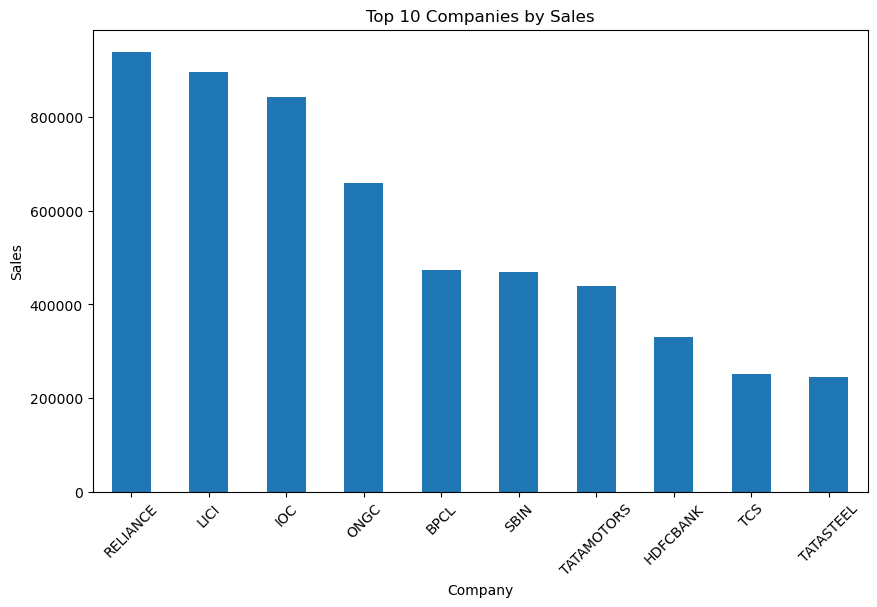

In [12]:
top_sales = (
    fact_profit_loss
    .groupby("symbol")["sales"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_sales.plot(kind="bar")

plt.title("Top 10 Companies by Sales")
plt.xlabel("Company")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

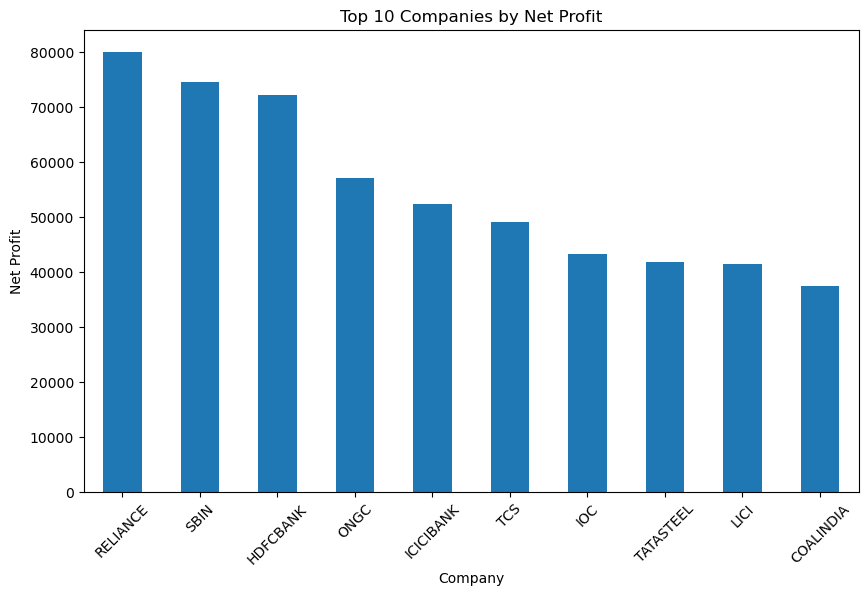

In [13]:
top_profit = (
    fact_profit_loss
    .groupby("symbol")["net_profit"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_profit.plot(kind="bar")

plt.title("Top 10 Companies by Net Profit")
plt.xlabel("Company")
plt.ylabel("Net Profit")
plt.xticks(rotation=45)

plt.show()

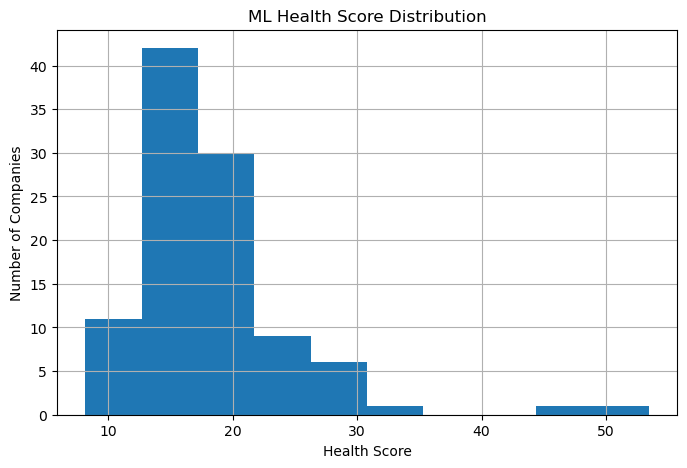

In [14]:
plt.figure(figsize=(8,5))

fact_ml_scores["overall_score"].hist(
    bins=10
)

plt.title("ML Health Score Distribution")
plt.xlabel("Health Score")
plt.ylabel("Number of Companies")

plt.show()

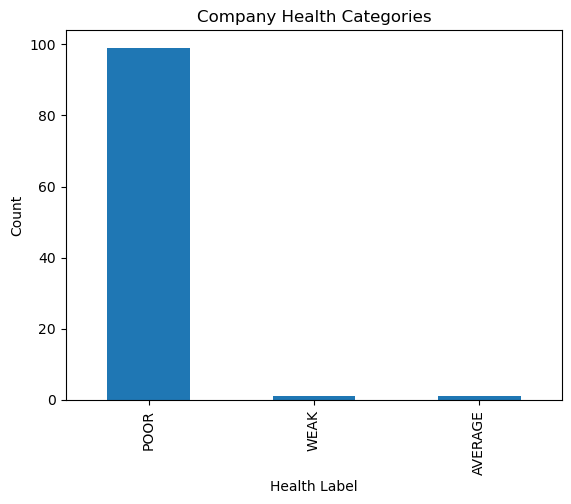

In [15]:
fact_ml_scores["health_label"].value_counts().plot(
    kind="bar"
)

plt.title("Company Health Categories")
plt.xlabel("Health Label")
plt.ylabel("Count")

plt.show()

In [16]:
fact_ml_scores.sort_values(
    "overall_score",
    ascending=False
).head(10)

,symbol,company_name,overall_score,health_label,computed_at
66,NESTLEIND,Nestle India Ltd,53.43,AVERAGE,2026-06-15 11:32:03.941917
38,HDFCBANK,HDFC Bank Ltd,45.95,WEAK,2026-06-15 11:32:03.941917
13,BAJAJHLDNG,Bajaj Holdings & Investment Ltd,31.27,POOR,2026-06-15 11:32:03.941917
86,TCS,Tata Consultancy Services Ltd,29.61,POOR,2026-06-15 11:32:03.941917
58,LICI,Life Insurance Corporation of India,29.16,POOR,2026-06-15 11:32:03.941917
25,COALINDIA,Coal India Ltd,28.93,POOR,2026-06-15 11:32:03.941917
48,INFY,Infosys Ltd,28.92,POOR,2026-06-15 11:32:03.941917
21,BRITANNIA,Britannia Industries Ltd,26.72,POOR,2026-06-15 11:32:03.941917
5,ADANIPOWER,Adani Power Ltd,26.32,POOR,2026-06-15 11:32:03.941917
50,IRCTC,Indian Railway Catering & Tourism Corporation Ltd,25.41,POOR,2026-06-15 11:32:03.941917
